# Gravitional fields 
For my computational data analysis project I am going to be exploring gravitional fields and the effect that they have within the universe. 
Within my project i will explore:
- the gravitiaional field strength around 1, 2 or N point masses
- the gravitional potential around 1,2 or N point masses
- the gravitional field and potential inside and outside of solid bodies and spherical shells
- Lagrange points between 2 masses within space
- the circular and elliptical orbits, energy and momentum conservation

While exploring these varies aspects of gravitational fields, I will state the theory, aswell as to using code to display and show these different functions and effects that they have on the universe.

What is a gravitational field?
- A gravitational field is a physical field that describes the influence that a mass has on the space around it, which causes other masses and objects such as light to experience a force of attraction

## Gravitational field strength around 1, 2 or N point masses
##### What is a gravitational field around a point mass ?
- The gravitational field at a distance r from a point mass M, is the force per unit mass of the test mass placed at that point. A point mass is an object whose mass is assumed to be concentrated at one specific point.
The mathematical expression that describes this is equation (1):
$$
g = \frac{GM}{r^2}
$$

Equation (1) represents the gravitational field g around any object with a mass M at a radius r from the centre of mass, where G represents the gravitational constant thus giving the relationship:
$$
g ∝ \frac{1}{r^2}
$$
Meaning that the gravitational field strength is inversely proportional to the square of the radius.

The gravitational field strength is a vector which is directed towards the mass of the object and can be represented by:
$$
\mathbf{g} = \frac{-GM}{r^2} \hat{r} =     \frac{-GM}{r^3} {(x,y,z)}   
$$

Therefore for the x, y and z components:
$$
f_x = \frac{-GMx}{(x^2 + y^2 + z^2)^(3/2)},  \qquad  f_y = \frac{-GMy}{(x^2 + y^2 + z^2)^(3/2)},   \qquad  f_z = \frac{-GMz}{(x^2 +y^2 +z^2)^(3/2)}
$$





I will create a graph below to show how equation (1) affects all masses within our universe.

From the graph, the value of g at the radius of the earth is 9.8 N/kg!
The value of the gravitational field strength g on Earth 50000000.0 metres from the centre of mass is 0.159 N/kg!
The value of the gravitational field strength g on the object with mass 1.99e+30 kg at a distance 695700000.0 metres from the centre of mass is 274.419 N/kg!


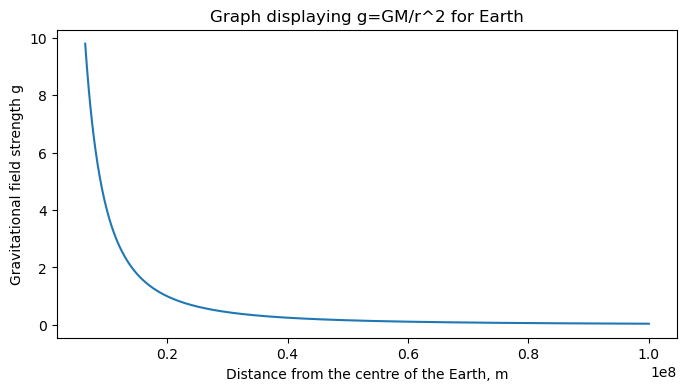

In [1129]:
# create a graph showing the relationship g∝1/r^2 using the values of earth
# make a function where distance from the surface of the earth can calculate a field strength at any position
# create another function that allows for the gravitational field strength to be calculated for another large point mass

# show a graph of g=GM/r^2
# create graph, similar code to my first graph, just add values now
# as code is after can use same symbols such as r and g

# define constants
G = sc.G
M = 5.972e24

# define r, range of r from surface and a large number for limit so can account for a large range , as g can vary inside
r = np.linspace(6.378e6, 10e7, 1000)
g = (G*M)/(r**2)

#create graph
fig, ax=plt.subplots(figsize=(8,4))
ax.plot(r,g)

#titles
ax.set_title('Graph displaying g=GM/r^2 for Earth')
ax.set_xlabel('Distance from the centre of the Earth, m')
ax.set_ylabel('Gravitational field strength g')

# to test relationship and graph, value obtained of g should be similar of that to the accepeted value of g = 9.81, obtained rsult should be around this value
#do this by using np.interp
g_value = np.interp(6.378e6,r,g)
print('From the graph, the value of g at the radius of the earth is',round(g_value,2),'N/kg!')

#create a function that calculates the field strength from any distance and position
#define a function, have the sentnece within the function so that it can be easily pasted
def g_Earth(R):
    g = (G*M)/(R**2)
    # use {} for values, f'' to make a sentence
    return f'The value of the gravitational field strength g on Earth {R} metres from the centre of mass is {round(g,3)} N/kg!'
#test the sentence 
print(g_Earth(5e7))

#now I am creating a function that calculates the gravitational field strength g for a mass that is not the Earth
#mass must be inputted by the person who wants to find the g
#distance from centre of mass and mass of the object will need to be inputted to find g of this object
def g_strength(Radius, Mass):
    g = (G*Mass)/(Radius**2)
    return f'The value of the gravitational field strength g on the object with mass {Mass} kg at a distance {Radius} metres from the centre of mass is {round(g,3)} N/kg!'

#test with object like sun, mass=1.99e30, radius=6.957e8, accepted value on surface is 274
print(g_strength(6.957e8,1.99e30))
#similar ot accepted value, therefore function works

The graph above displayes the relationship between g and r in equation 1. As you get closer to the mass, the gravitational field strength increases, and as you get further away from the mass the field strength decreases. I have created this specific graph to display how the gravitational field strength is affected when the distance is varied on Earth, however the shape of the graph, represents the same for all masses. For other masses, the graph may be less or more steep. I have additionally built in functions allowing for g to be calculated, from the graph, and equations for Earth and other masses.

I am now going to display the effect of how a point mass affects the environment around it, causing it to be an attracting force, I will use a vector field to simply show how it causes variation in the space around it.

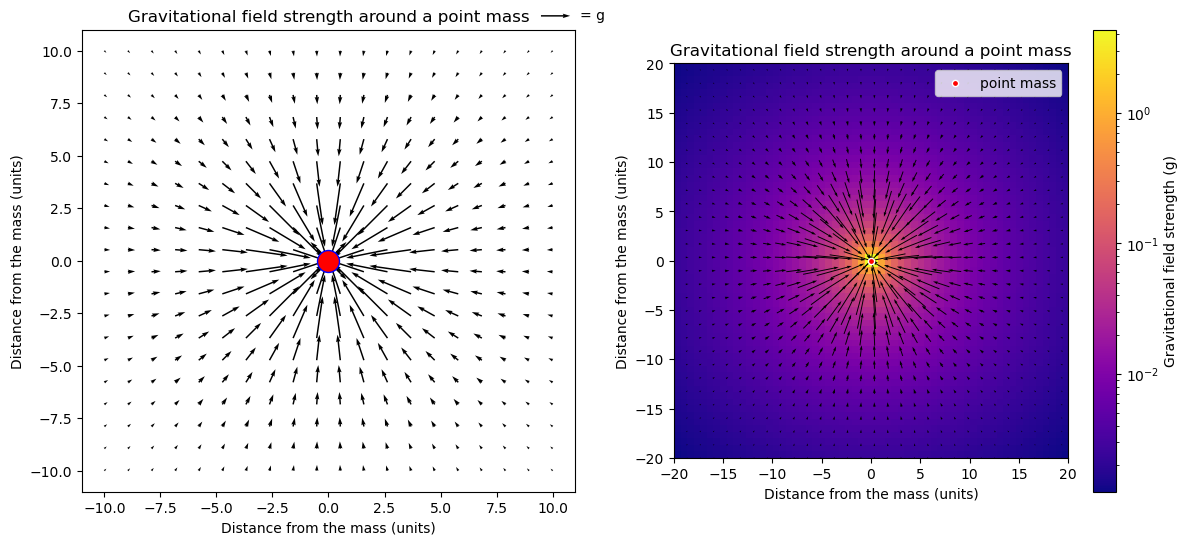

In [1132]:
# im going to display two 2d vector graphs of the gravitational fields around a point mass that will show how the distance affects the field strength
# first graph to show the field, second to use a cmap to see how the space changes
import numpy as np
import matplotlib.pyplot as plt
import scipy.constants as sc

######first graph######

#define ranges of x and y
# as one point, xrange = yrange, 
# -10 to 10 so data is around the origin
x1_range = y1_range = np.linspace(-10,10,20)

# write x and y as a meshgrid with the ranges

x1, y1  = np.meshgrid(x1_range, y1_range)

#for simplicity m,g=1
mass = 1
G  =1

# only x and y components needed as a 2d graph
fx1 = (-G * mass * x1)/(x1**2 + y1**2 + 1e-9)**(3/2)
fy1 = (-G * mass * y1)/(x1**2 + y1**2 + 1e-9)**(3/2)

# A problem was happening where there were long horizontal lines, and outward arrows, not correct for a field strength plot
# clipping the largest vectors to prevent arrows near the origin becoming too long, due to as r->0, magnitude becomes very high
# code altered from chatgpt to solve this problem of the large lines which cause disruption

# find the magnitude of each vector
mag1 = np.sqrt(fx1**2 + fy1**2)

#cap the vector to a max allowed size
cap1 = np.percentile(mag1, 90)

#scale each vector by getting the scalar factor
scale_factor1 = np.minimum(1,cap1/mag1)

#scale the vectors
fx1 = fx1 * scale_factor1
fy1 = fy1 * scale_factor1

# plot the vector
fig, ax = plt.subplots(1,2,figsize=(14,6))

# to improve visually add a point at 0,0, use quiver 
Q = ax[0].quiver(x1,y1,fx1,fy1)

# use quiverkey to show arrow, allowing for the direction of the vector field to be easily understood
ax[0].quiverkey(Q,0.99,1.03,0.05,'= g',labelpos='E')

# use plt.scatter and an edgecolor so can be easily seen
ax[0].scatter(0,0,color='red',edgecolor='blue',s=250,zorder=3)
#titles
ax[0].set_title('Gravitational field strength around a point mass')
ax[0].set_ylabel('Distance from the mass (units)')
ax[0].set_xlabel('Distance from the mass (units)')


#####second graph######


#other graph , get it next to it on the right by using ax[], change final bits of first graph to do this -> ax[0]

#For this graph i will use a cmap, to further show how the space is changed by the vector field

# coding for this has been adapted and learnt from Visualizing vector fields by physics with nero, youtube video
# where i have adapted the code and altered it to show the vector clearly

# set the ranges, meshgrid and fx,fy components
x2_range = y2_range = np.linspace(-20,20,60)
x2, y2 = np.meshgrid(x2_range, y2_range)
fx2 = (-G * mass * x2)/(x2**2 + y2**2 + 1e-9)**(3/2)
fy2 = (-G * mass * y2)/(x2**2 + y2**2 + 1e-9)**(3/2)

#this code stops caps the outwards arrows by minimsing the large values
f2_mag = np.sqrt(fx2**2 +fy2**2)
# same code as before copied over
mag2 = np.sqrt(fx2**2 + fy2**2)
#cap the vector to a max allowed size
cap2 = np.percentile(mag2, 95)
#scale each vector by getting the scalar factor
scale_factor2 = np.minimum(1,cap2/mag2)
#scale the vectors
fx2 = fx2 * scale_factor2
fy2 = fy2 * scale_factor2

#Use lognorm so more colours can be seen, showing a wider rnage on the graph
from matplotlib.colors import LogNorm

# use ax.imshow for colour mapping
img = ax[1].imshow(f2_mag, origin = 'lower', extent = (-20,20,-20,20),cmap='plasma',norm=LogNorm())

#ax.quiver to display vector
ax[1].quiver(x2[::2,::2],y2[::2,::2],fx2[::2,::2],fy2[::2,::2],color='black',pivot='middle')
ax[1].set_title('Gravitational field strength around a point mass')

# colourbar to show the increasing gravitational field strength towards that centre of the point mass
fig.colorbar(img, label='Gravitational field strength (g)',cmap='plasma')
ax[1].set_ylabel('Distance from the mass (units)')
ax[1].set_xlabel('Distance from the mass (units)')

# add a point mass onto the cetnre of the graph, to help showing the field, small so cmap isnt affected
ax[1].scatter(0,0,color='red',edgecolor='white',s=20, label = 'point mass')
ax[1].legend()

plt.show()

These two graphs show how space varies around a point mass with g quickly icnreasing the closer it gets to the point mass, the vectors increase sharply presenting on how the field strength increases when near the point mass. These graphs follow equation (1) and clealy display the effect they have on the space around it.

Below I will display the effect that 2 and 5 point masses have on a system, this will enable for the idea of g to be understood, I will display with a cmap so that the field strength can be easily displayed and identified to when g is changing around the masses.
I will also use a vector field on these graphs, showing the sudden increase in g that occurs near the mass as it follows equation (1).

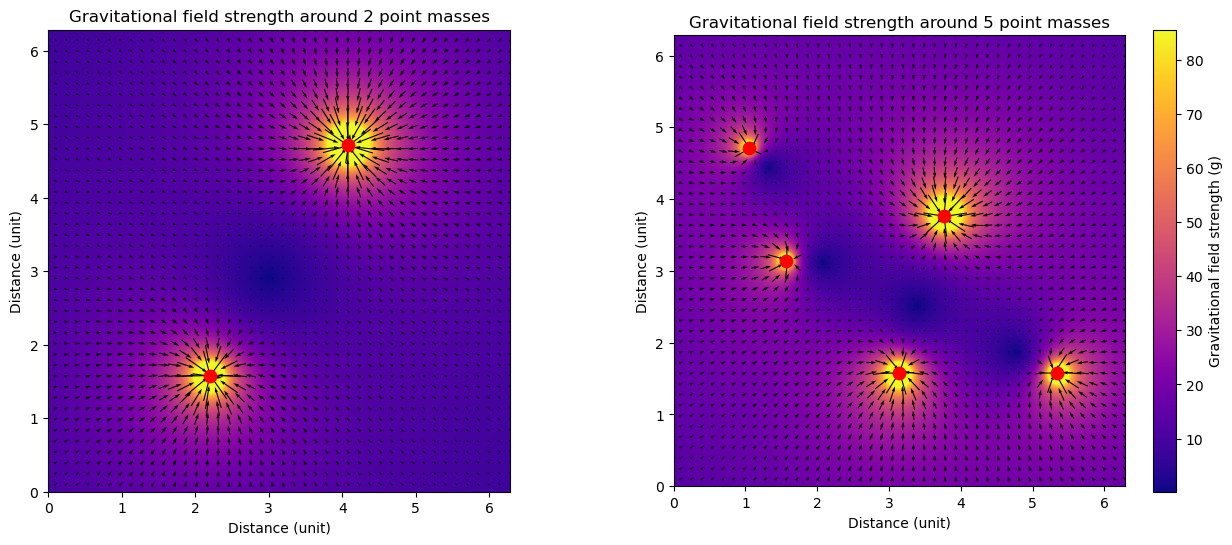

In [1139]:
# create a graph showing the gravitational potential around 2 and 5 point masses that are plotted on a 2d vector graph

# start with 2 and increase, develop code once these two have been produced
x_range = y_range = np.linspace(0,2*np.pi,300)
x, y = np.meshgrid(x_range, y_range)

#as potential around a point mass are circular
#define the points
p1 = (1.3*np.pi, 1.5*np.pi)
p2 = (0.7*np.pi, 0.5*np.pi)

# using absolute value so doesnt matter if accidentally put a negative number in
mass1 = np.abs(20)
mass2 = np.abs(15)
G = 1

# find the displacement from x to each point
# dx = x - xpart of p

#point 1
dx1 = x - p1[0]
dy1 = y - p1[1]

#calculate the distance, dx**2 + dy**2 *^1/2
r1 = np.sqrt(dx1**2 + dy1**2)


# write out field strength 
g1x = (-G * mass1 * dx1)/r1**2
g1y = (-G * mass1 * dy1)/r1**2

#same for point 2
dx2 = x - p2[0]
dy2 = y - p2[1]
r2 = np.sqrt(dx2**2 + dy2**2)
g2x = (-G * mass2 * dx2)/r2**2
g2y = (-G * mass2 * dy2)/r2**2

#find the total vector field, the interaction that both points have on each other
gx = g1x + g2x
gy = g1y + g2y

# copied over, to remove arrows that are pointing out due to magnitude being very large
mag1 = np.sqrt(gx**2 + gy**2)

#cap the vector to a max allowed size
cap1 = np.percentile(mag1, 99)

#scale each vector by getting the scalar factor
scale_factor1 = np.minimum(1,cap1/mag1)

#scale the vectors
gx = gx * scale_factor1
gy = gy * scale_factor1

f_mag = np.sqrt(gx**2 + gy**2)

#plot the first graph of two points
fig, ax = plt.subplots(1,2,figsize=(16,6))
# use imshow and define it so it can be used in the colourbar, make cmap colour for presentation
Gstrength = ax[0].imshow(f_mag, origin = 'lower', extent= (0,2*np.pi,0,2*np.pi), cmap='plasma')
# show the vectors using quiver
ax[0].quiver(x[5::7,5::7],y[5::7,5::7],gx[5::7,5::7],gy[5::7,5::7],pivot='middle',color='black')
#vector field shows but not points, add points onto the graph by scatter
ax[0].scatter([p1[0],p2[0]],[p1[1],p2[1]],color='red',s=80, zorder=50)

# add title etc
ax[0].set_xlabel('Distance (unit)')
ax[0].set_ylabel('Distance (unit)')
ax[0].set_title('Gravitational field strength around 2 point masses')

#####Second graph######

# For this code i will create a rough graviational field of 5 point masses which shows a larger variation of the gravitational fields 
# that occur when there are more bodies

# As i have copied the code over, and am placing it in the same cell as the previous to improve the visualisation, 
# I am adding _2 to the end of the variables that would be found when copied over so that they don't interfere with each other 

x_range_2 = y_range_2 = np.linspace(0,2*np.pi,300)
x_2, y_2 = np.meshgrid(x_range_2, y_range_2)

#as potential aroudn a point mass are circular
#define the points
p1_2 = (np.pi/2, np.pi)
p2_2 = (np.pi, np.pi/2)

# give more points
p3_2 = (1.2*np.pi,1.2*np.pi)
p4_2 = (np.pi/3, 1.5*np.pi)
p5_2 = (1.7*np.pi,0.5*np.pi)

# using absolute value so doesnt matter if accidentally put a negative number in
mass1_2 = np.abs(8)
mass2_2 = np.abs(15)
mass3_2 = np.abs(20)
mass4_2 = np.abs(7)
mass5_2 = np.abs(12)
G = 1

# find the displacement from x to each point
# dx = x - xpart of p
#point 1
dx1_2 = x_2 - p1_2[0]
dy1_2 = y_2 - p1_2[1]

#calculate the distance, dx**2 + dy**2 *^1/2
r1_2 = np.sqrt(dx1_2**2 + dy1_2**2)

# write out the field strength
g1x_2 = (-G * mass1_2 * dx1_2)/r1_2**2
g1y_2 = (-G * mass1_2 * dy1_2)/r1_2**2

#same for point 2
dx2_2 = x_2 - p2_2[0]
dy2_2 = y_2 - p2_2[1]
r2_2 = np.sqrt(dx2_2**2 + dy2_2**2)
g2x_2 = (-G * mass2_2 * dx2_2)/r2_2**2
g2y_2 = (-G * mass2_2 * dy2_2)/r2_2**2

#for point 3 
dx3_2 = x_2 - p3_2[0]
dy3_2 = y_2 - p3_2[1]
r3_2 = np.sqrt(dx3_2**2 + dy3_2**2)
g3x_2 = (-G * mass3_2 * dx3_2)/r3_2**2
g3y_2 = (-G * mass3_2 * dy3_2)/r3_2**2

#for point 4
dx4_2 = x_2 - p4_2[0]
dy4_2 = y_2 - p4_2[1]
r4_2 = np.sqrt(dx4_2**2 + dy4_2**2)
g4x_2 = (-G * mass4_2 * dx4_2)/r4_2**2
g4y_2 = (-G * mass4_2 * dy4_2)/r4_2**2

#for point 5
dx5_2 = x_2 - p5_2[0]
dy5_2 = y_2 - p5_2[1]
r5_2 = np.sqrt(dx5_2**2 + dy5_2**2)
g5x_2 = (-G * mass5_2 * dx5_2)/r5_2**2
g5y_2 = (-G * mass5_2 * dy5_2)/r5_2**2

#find the total vector field, the interaction that 5 points have on each other
gx_2 = g1x_2 + g2x_2 + g3x_2 + g4x_2 + g5x_2
gy_2 = g1y_2 + g2y_2 + g3y_2 + g4y_2 + g5y_2

# copied over, to remove arrows that are pointing out due to magnitude being very large
mag1_2 = np.sqrt(gx_2**2 + gy_2**2)

#cap the vector to a max allowed size
cap1_2 = np.percentile(mag1_2, 99)

#scale each vector by getting the scalar factor
scale_factor1_2 = np.minimum(1,cap1_2/mag1_2)

#scale the vectors
gx_2 = gx_2 * scale_factor1_2
gy_2 = gy_2 * scale_factor1_2

f_mag_2 = np.sqrt(gx_2**2 + gy_2**2)

# Gstrength = imshow, so can be used in the colourbar
Gstrength_2 = ax[1].imshow(f_mag_2, origin = 'lower', extent= (0,2*np.pi,0,2*np.pi), cmap='plasma')
#quiver so that vector graph will appear on the graph
ax[1].quiver(x_2[5::7,5::7],y_2[5::7,5::7],gx_2[5::7,5::7],gy_2[5::7,5::7],pivot='middle',color='black')
#vector field shows but not points, add points onto the graph by scatter
ax[1].scatter([p1_2[0],p2_2[0],p3_2[0],p4_2[0],p5_2[0]],[p1_2[1],p2_2[1],p3_2[1],p4_2[1],p5_2[1]],color='red',s=80, zorder=50)

#add a colour bar to display the values of g
# only adding for this graph as will be the same colours so only one key needed
fig.colorbar(Gstrength_2, label='Gravitational field strength (g)', cmap='plasma')

# add title etc
ax[1].set_xlabel('Distance (unit)')
ax[1].set_ylabel('Distance (unit)')
ax[1].set_title('Gravitational field strength around 5 point masses')

plt.show()

For both of these graphs, you can change the values of the x and y coords in the p1-p2, p1_2 - p5_2 to change the position of the point masses on the graph which will affect the position and angle of the vector field. You can also change the strength of the vector field by changing the values of the mass1-mass2 and mass1_2 - mass5_2!

On the graph, the dark patches of purple is where the points of equilibrium are located and g is weak. As the colour changes up the colourbar the g increases. This is shown by the the colour around the point masses being yellow, where the distance is small so g is large, and alternatively for when far from the point masses where it is purple.

Most systems in space can be thought of in similar ways as these, being point masses due to the size of the masses being mostly negligible when considering the massive size of space.

## The gravitional potential around 1,2 or N point masses
##### What is the gravitational potential?
- The gravitational potential is the work done per unit mass to bring a point from infinity (or a reference point) to a specific point within a gravitational field. The mathematical equation that describes this is equation(2):
$$
V = \frac{-GM}{r}
$$

Equation (2) represents the gravitional potential V, for any object a distance r from the centre of mass M of the object. This value is always negative due to work being done against a point the gravitational field, gravity being attractive, and being defined as having a value of 0 at infinity, additionally it is the potential energy per unit mass, meaning the gravitational potential energy ,U, is:

$$
U = \frac{-GMm}{r}
$$
Where m is the test mass affected by the gravitational attraction force.

From equation (2), we are given the relationship:

$$
V ∝ \frac{1}{r}
$$
Showing a the gravitational potential has an inversely proportional relationship with distance.

The potential itself can be displayed as:
$$
V = \frac{-GM}{\sqrt(x^2 + y^2 + z^2)}
$$
Furthermore, as the gravitational potential is a scalar, multiple potentials can be added if there are N masses, so that:

$$
V = -G \sum_{i=1}^{N} \frac{M_i}{r_i}
$$

Below I will present the graph showing the inversely proportional relationship between V and r in equation 2, which is followed by all masses. I will then show how the gravitational potential field varies around a point mass. For this i will aim for there to be circles around the point mass, and points of equipotential where the gravitational potential is constant.

Aswell I will provide functions which can be used to calculate the gravitational potential and gravitational potential energy around a point mass.

The gravitational potential at a distance of 6378000.0 metres from the centre of the Earth is -62494386.328002505 J/Kg!
The gravitational potential at a distance 695700000.0 metres from the object of mass 1.99e+30 kg, is -190913569067.12662 J/Kg!
The value of the gpe U for an object of mass 1 kg at a distance of 6378000.0 metres from the centre fo the Earth is -62494386.328002505 J!
The value of the gpe U for an object of mass 1 kg to a larger mass 1.99e+30 kg at a distance of 695700000.0 metres is -190913569067.12662 J!


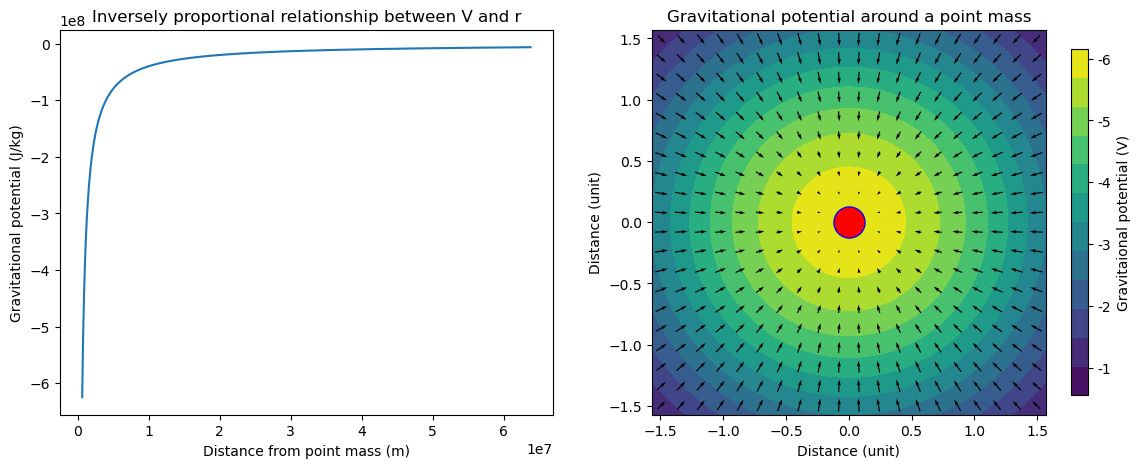

In [1143]:
# create a graph showing the inversely proportional relationship V∝1/r and functions that can display the energy and potential 
# as well as a contour graph showing the equipotential positions around a point mass
# show using Earth as an example, mass of Earth as a point mass

#define constants
G = sc.G
M = 5.972e24
r_earth = 6.378e6 

#define range
r = np.linspace(0.1*r_earth,10*r_earth,1000)

# V equation
V = -G*M/r

# plot r against v
fig,ax =plt.subplots(1,2,figsize=(14,5))
ax[0].plot(r,V)
#labels
ax[0].set_title('Inversely proportional relationship between V and r')
ax[0].set_xlabel('Distance from point mass (m)')
ax[0].set_ylabel('Gravitational potential (J/kg)')


#####Define functions#####


#create a function to calculate the gravitational potential for a point on Earth, return the distance from the surface of the earth
#function should include the value of radius

def V_Earth(r) :
    return f'The gravitational potential at a distance of {r+r_earth} metres from the centre of the Earth is {(-G*M)/(r+6.378e6)} J/Kg!'
#test and print the function at the radius of the earth to test if value works, accpeted value is from -(60)MJ -> (-63)MJ
print(V_Earth(0))

# do the same but now for a point mass that is not the Earth, as not the earth and another mass the radius is unknown within the function
# distance from the point mass will have to be inserted into the function, mass in kg and distance from point mass in metres

def V_object(r,m):
    return f'The gravitational potential at a distance {r} metres from the object of mass {m} kg, is {(-G*m)/(r)} J/Kg!'
#test on an accepted celestial object, the sun, mass = 1.99e30, radius = 6.957e8, accepeted value is -1.9e11
print(V_object(6.957e8, 1.99e30))

# now create a function for the gravitational potential energy
# do for Earth and for other objects
# M is the mass of the larger object and m is the mass of the smaller, however can be switched when writing the function as multiply each other

def U_Earth(r, m) :
    return f'The value of the gpe U for an object of mass {m} kg at a distance of {r} metres from the centre fo the Earth is {(-G*m*5.972e24)/r} J!'
#test with value of Earth at radius which has an accpeted value of (-62.5MJ/kg)->(-63MJ/kg) per kilogram
#for simplicity to test the function i will use the mass of the smaller object to be 1kg
print(U_Earth(6.378e6,1))


#now do the same for an object that is not the Earth
# Mass of the object will have to be inputed as will be unkown to function
    
def U_object(r,M,m):
    return f'The value of the gpe U for an object of mass {m} kg to a larger mass {M} kg at a distance of {r} metres is {(-G*M*m)/r} J!'
#test value of the sun, which has an accepted gpe at the radius of 
#accepted value of V is -1.9e11
print(U_object(6.957e8, 1.99e30, 1))


#####Second graph#####


# create a 2d contour graph showing that the further you go from the point mass, the greater the gravitational potential
# This graph just displays what the potential around 1 point mass would apppear like

import numpy as np
import matplotlib.pyplot as plt
import scipy.constants as sc

# as is around a point mass, the gravitational equipotential lines will all be the same, so can be displayed via a circle

#define x and y
def f(x, y):
    return np.cos(np.sqrt(x**2 + y**2))
    
# do the range of x and y
x_range = np.linspace(-np.pi/2,np.pi/2,201)
y_range = np.linspace(-np.pi/2,np.pi/2,201)

#use np.meshgrid for the range of x and y
x, y = np.meshgrid(x_range, y_range)

#define dx dy by np.gradient
dfdy, dfdx = np.gradient(f(x,y),np.pi/100)

# contourf instead of contour fills the equipotential lines, improving aesthetic
# use a different cmap to g, showing difference

# use contourf to create a filled contour plot, showing the equipotential lines
Potential = plt.contourf(x, y, f(x,y),levels=10,cmap='viridis')

# use quiver for vectors, scatter for point mass
A = plt.quiver(x[5::10,5::10],y[5::10,5::10],dfdx[5::10,5::10],dfdy[5::10,5::10], pivot='middle')
ax[1].scatter(0,0,color='red',edgecolor='blue',s=500,zorder=3)

#set title
ax[1].set_title('Gravitational potential around a point mass')


# add a colour bar so can be seen that the further away from the point mass the greater the V
cbar = plt.colorbar(Potential, label='Gravitaional potential (V)',shrink=0.9)

# use ticks and set_ticks to set colour bar, reverting so highest value is closest to the centre
ticks = np.linspace(f(x,y).min(),f(x,y).max(), 6)
cbar.set_ticks(ticks)
cbar.set_ticklabels(['-1','-2','-3','-4','-5','-6'])

#labels
ax[1].set_xlabel('Distance (unit)')
ax[1].set_ylabel('Distance (unit)')
 
plt.show()

The graph on the left shows the inversely proportional relationship between the gravitational potential and distance, as distance increases the potential decreases and vice versa. This graph is presented for the Earth, however all masses will have a potential curve like this one, where it may be slightly different. 

The graph on the right has equipotential points where the colours change, showing the lines of constant potential around a point mass. As it is a point mass, the equipotential points can be taken to be circular around the mass. These ciruclar lines all have a constant radius to the point mass. The colour on the graph shows that the closer you get to the mass the greater the gravitational potential by using a yellow colour, and the further away you are the weaker teh gravitaitonal potential, shown by a dark blue/ purple.

Additionally, I have added functions that calculate the gravitational potential and gravitational potential energy for masses around Earth, and for other objects.

For the graphs below, I want to present the gravitational potential for multiple bodies and display how it will affect the potential of the system. I will use a cmap to easily display the potential. This will show how the potentials add up, as they are a scalar, for multiple masses for the overall potential of a system to combine at one point. By doing a 3 point mass system, I can display this clearly.

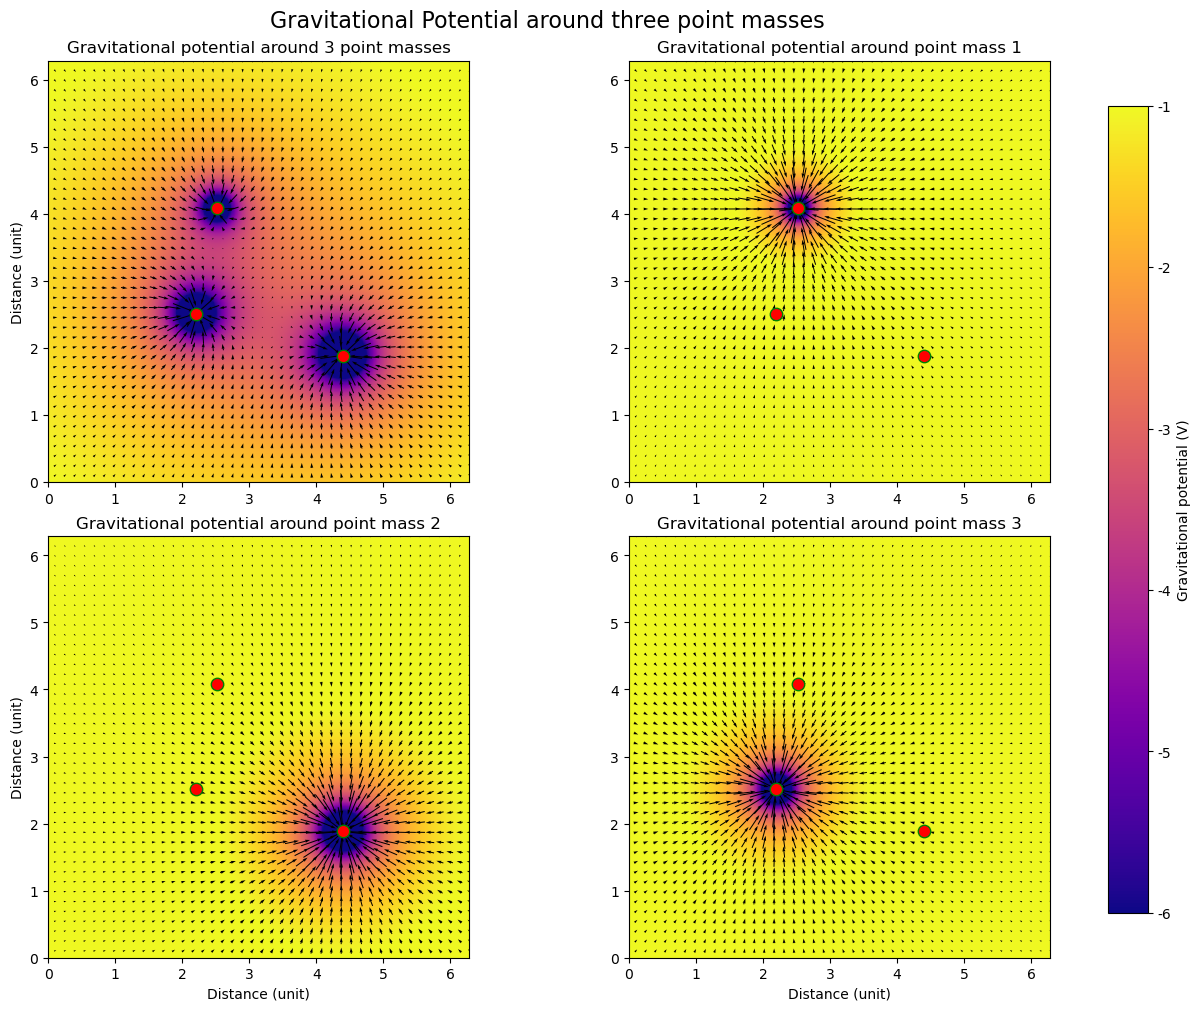

In [1145]:
# To show the gravitational potential for multiple point masses, i will copy my code over for the gravitational field strength point masses graph
# and will adjust its so the larger the potential the further from the centre
# this can be done by manually changing the axis so that the deeper the colour on the graph, the further away from the point mass and thus more potential

#####First graph#####


# create a graph showing the gravitational potential around 2 and 5 point masses that are plotted on a 2d vector graph
# start with 2 and increase, develop code once these two have been produced
# define range
x_range = y_range = np.linspace(0,2*np.pi,300)
x, y = np.meshgrid(x_range, y_range)

#as potential aroudn a point mass are circular
#define the points
p1 = (0.8*np.pi, 1.3*np.pi)
p2 = (1.4*np.pi, 0.6*np.pi)
p3 = (0.7*np.pi, 0.8*np.pi)

# using absolute value so doesnt matter if accidentally put a negative number in
mass1 = np.abs(2)
mass2 = np.abs(4)
mass3 = np.abs(3)
G = 1

# find the displacement from x to each point
# dx = x - xpart of p
#point 1
dx1 = x - p1[0]
dy1 = y - p1[1]

#calculate the distance, dx**2 + dy**2 *^1/2
r1 = np.sqrt(dx1**2 + dy1**2)

# define potentials for point one
v1x = (-G * mass1 * dx1)/r1**2
v1y = (-G * mass1 * dy1)/r1**2

#same for point 2
dx2 = x - p2[0]
dy2 = y - p2[1]
r2 = np.sqrt(dx2**2 + dy2**2)
v2x = (-G * mass2 * dx2)/r2**2
v2y = (-G * mass2 * dy2)/r2**2

#same now for point 3
dx3 = x - p3[0]
dy3 = y - p3[1]
r3 = np.sqrt(dx3**2 + dy3**2)
v3x = (-G * mass3 * dx3)/r3**2
v3y = (-G * mass3 * dy3)/r3**2

#find the total vector field, the interaction that both points have on each other
vx = v1x + v2x + v3x
vy = v1y + v2y + v3y

# copied over, to remove arrows that are pointing out due to magnitude being very large
mag1 = np.sqrt(vx**2 + vy**2)

#cap the vector to a max allowed size
cap1 = np.percentile(mag1, 99)

#scale each vector by getting the scalar factor
scale_factor1 = np.minimum(1,cap1/mag1)

#scale the vectors
vx = vx * scale_factor1
vy = vy * scale_factor1

f_mag = np.sqrt(vx**2 + vy**2)

#creat the plot
fig, ax = plt.subplots(2,2,figsize=(13,10),constrained_layout=True)

# As potential is a gravitational scalar the points can be added
# keep positive so that the vector field gets a darker colour further away
v1 = -G*mass1/r1
v2 = -G*mass2/r2
v3 = -G*mass3/r3
V = v1 + v2 + v3
# use np.percentile to reduce any very large results which could cause vector to be disrupted
Vmin = np.percentile(V,2)
Vmax = np.percentile(V,98)

#use imshow, define so can use on the colour bar
Vstrength = ax[0,0].imshow(V, origin = 'lower', extent= (0,2*np.pi,0,2*np.pi), cmap='plasma',vmin=Vmin, vmax=Vmax)
# use quiver to show vectors
ax[0,0].quiver(x[5::7,5::7],y[5::7,5::7],vx[5::7,5::7],vy[5::7,5::7],pivot='middle',color='black')

# add title etc
ax[0,0].set_ylabel('Distance (unit)')
ax[0,0].set_title('Gravitational potential around 3 point masses')

#vector field shows but not points, add points onto the graph by scatter
ax[0,0].scatter([p1[0],p2[0],p3[0]],[p1[1],p2[1],p3[1]],color='red',edgecolor='green',s=80, zorder=50)


####Second graph#####


# as previous graph as potentials interfering, create 3 graphs, one for each mass of only their potential
# ill simply just copy the graphing section across onto this part, change it from ax[0] to ax[1] and remove the potentials for points not wanted
# will keep all points to show for the potential being unaffected and that it is a scalar
# go back to preivous code and define V with v1, v2, v3

# copied over, to remove arrows that are pointing out due to magnitude being very large
mag1_1 = np.sqrt(v1x**2 + v1y**2)

#cap the vector to a max allowed size
cap1_1 = np.percentile(mag1_1, 99)

#scale each vector by getting the scalar factor
scale_factor1_1 = np.minimum(1,cap1_1/mag1_1)

#scale the vectors
v1x = v1x * scale_factor1_1
v1y = v1y * scale_factor1_1

#same plot, imshow, quiver scatter to plot points
ax[0,1].imshow(v1, origin = 'lower', extent= (0,2*np.pi,0,2*np.pi), cmap='plasma',vmin=Vmin, vmax=Vmax)
ax[0,1].quiver(x[5::7,5::7],y[5::7,5::7],v1x[5::7,5::7],v1y[5::7,5::7],pivot='middle',color='black')
ax[0,1].set_title('Gravitational potential around point mass 1')
ax[0,1].scatter([p1[0],p2[0],p3[0]],[p1[1],p2[1],p3[1]],color='red',edgecolor='green',s=80, zorder=50)
# changed the ax[1]=imshow plot to have v1 instead of v, which removed the colour and V from the other points



######Third graph#####



# repeat of previous

# Graph for the second point mass
mag2 = np.sqrt(v2x**2 + v2y**2)

#cap the vector to a max allowed size
cap2 = np.percentile(mag2, 99)

#scale each vector by getting the scalar factor
scale_factor2 = np.minimum(1,cap2/mag2)

#scale the vectors
v2x = v2x * scale_factor2
v2y = v2y * scale_factor2

#same plot, imshow, quiver scatter to plot points
ax[1,0].imshow(v2, origin = 'lower', extent= (0,2*np.pi,0,2*np.pi), cmap='plasma',vmin=Vmin, vmax=Vmax)
ax[1,0].quiver(x[5::7,5::7],y[5::7,5::7],v2x[5::7,5::7],v2y[5::7,5::7],pivot='middle',color='black')
ax[1,0].set_xlabel('Distance (unit)')
ax[1,0].set_ylabel('Distance (unit)')
ax[1,0].set_title('Gravitational potential around point mass 2')
ax[1,0].scatter([p1[0],p2[0],p3[0]],[p1[1],p2[1],p3[1]],color='red',edgecolor='green',s=80, zorder=50)



####Fourth graph#####



# Graph for the third point mass
mag3 = np.sqrt(v3x**2 + v3y**2)

#cap the vector to a max allowed size
cap3 = np.percentile(mag3, 99)

#scale each vector by getting the scalar factor
scale_factor3 = np.minimum(1,cap3/mag3)

#scale the vectors
v3x = v3x * scale_factor3
v3y = v3y * scale_factor3

#same plot, imshow, quiver scatter to plot points
ax[1,1].imshow(v3, origin = 'lower', extent= (0,2*np.pi,0,2*np.pi), cmap='plasma',vmin=Vmin, vmax=Vmax)
ax[1,1].quiver(x[5::7,5::7],y[5::7,5::7],v3x[5::7,5::7],v3y[5::7,5::7],pivot='middle',color='black')
ax[1,1].set_xlabel('Distance (unit)')
ax[1,1].set_title('Gravitational potential around point mass 3')
ax[1,1].scatter([p1[0],p2[0],p3[0]],[p1[1],p2[1],p3[1]],color='red',edgecolor='green',s=80, zorder=50)

##details##

fig.suptitle("Gravitational Potential around three point masses", fontsize=16)

# will remove the axis titles for the sides in the centre, make it less clustered

# set a range on the colours
# sorted by setting ticks on the colourbar
# i will add one colourbar on the right side of the graph so its clear

# learnt from chatgpt in gravitational field strength section
# define the colourbar with vstrength in
cbar = fig.colorbar(Vstrength, ax=ax,label='Gravitational potential (V)', location='right', shrink=0.9)
# use linspace for ticks
ticks = np.linspace(Vmin,Vmax, 6)
#set ticks with labels
cbar.set_ticks(ticks)
cbar.set_ticklabels(['-6','-5','-4','-3','-2','-1'])

plt.show()

The graph of the 'Gravitational potential around 3 point masses' is effective at showing the potential for 3 point masses, the potentials add/superpose with each other in the centre of the top left graph, the next graphs display what the potential of each mass would actually be. As the potential is a scalar, these individual potentials can then be added to find the overall potential of the system. 

All the graphs show the potential is largest at the points closest to the point mass, and the potential being smallest when far away. The superposition is shown from the top left graph where the centre is a dark orange/pink, indicating on the colourbar to have a -3 potential. When looking at the other 3 graphs in the centre, a potential of -1 is found in the centre of each, being yellow. The potentials have therefore superposed in the top left graph, showing the overall potential at any point, whereas the other graphs show the potential at any point when only considering the potential around one mass. These show that the potential is a scalar which can be added to find the overall potential within a system.

Similar to the graphs in the gravitational field strength part, the values of the masses and positions can be changed.

## The gravitional field and potential inside and outside of solid bodies and spherical shells

The gravitational field strength and gravitational potential vary depending the location of the specific point for spherical shells and uniform solid bodies. When outside of a body, the object can be assumed as a point mass and you can use equation (1) and (2) to find your gravitational field strength and gravitational potential. However when you then enter the body of the object, going past the radius, these equations may no longer work and other equations are requried to find this field strength. 
#### For a uniform solid body of mass M, radius R:
##### Outside of the body, r≥R:
A uniform body can be assumed to be a point mass. So:
$$g = \frac{GM}{r^2} \qquad V = \frac{-GM}{r} $$

##### Inside of the body, r<R:
$$g = \frac {GMr}{R^3}  \qquad V = -\frac{GM}{2 R^3} {(3 R^2 - r^2)} $$


#### For a spherical shell of mass M, radius R:
##### Outside of the shell, r≥R:
$$g = \frac{GM}{r^2}  \qquad V = -\frac{GM}{r} $$

##### Inside of the shell, r<R:
$$ g = 0  \qquad V = -\frac{GM}{R}  $$

Due to outside of the body the uniform solid bodies and spherical shells can be assumed as of a point mass, the vector fields graphs would look the same as the ones computed earlier. So I will produce a graph of the gravitational field strength and potential against the distance from the centre. I will plot both field strength and potential graphs with inside and outside on the same graph, and have  a vertical line at the distance of the radius seperating them, clearly showing the difference in g and V.

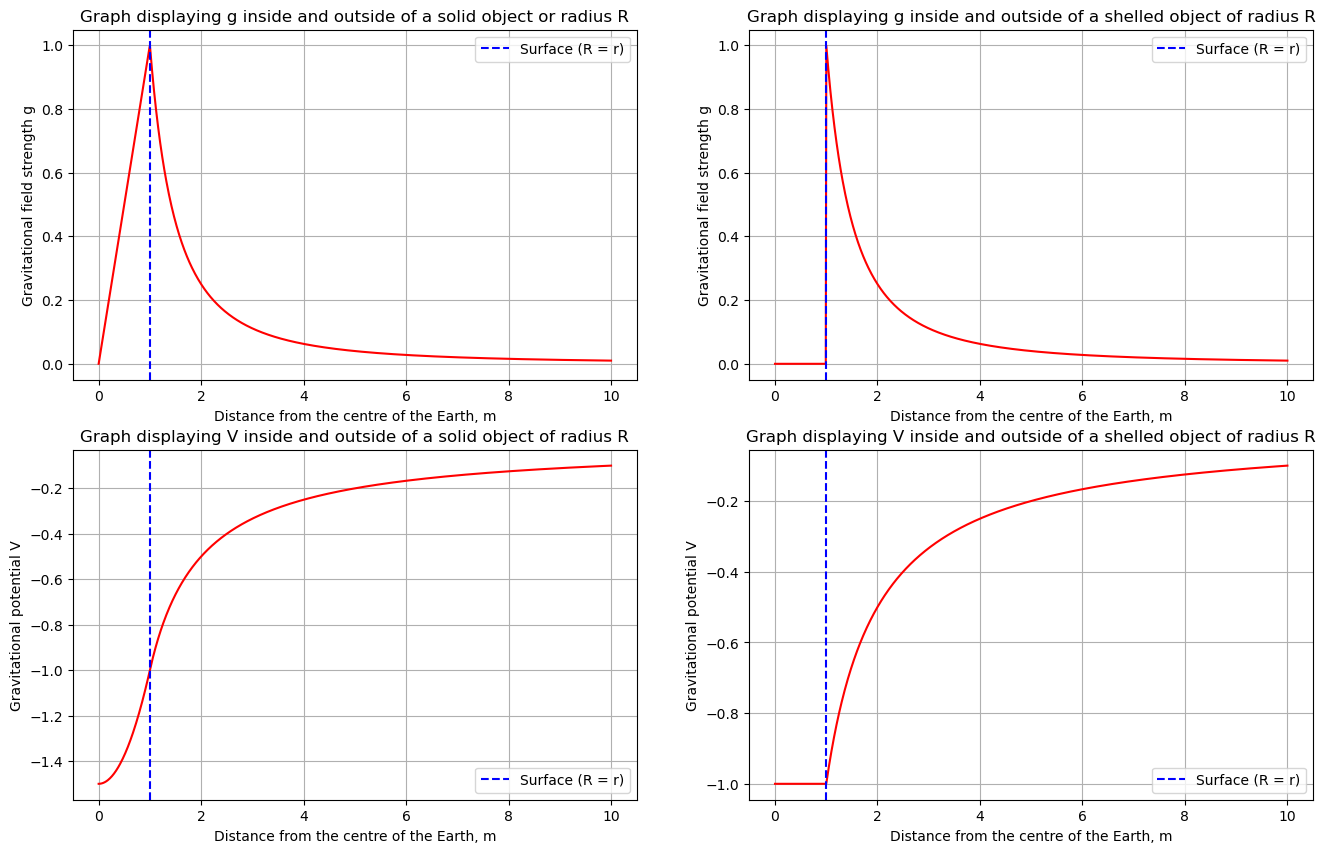

In [1146]:
# create a graph displaying all of the equations, 8 equations in total, start with graphs of g
# as i already computed this graph earlier i can copy it in and add the section for inside

# for ease, G=1 , M=1, r=1, r = radius, R = distance from the centre
G = 1
M = 1
r = 1

# define r and g
R = np.linspace(0, 10*r, 1000)
g_u = np.zeros_like(R)

# define whether object is inside or outside
outside = R>= r 
inside = R < r

#add the outside and inside to the formula of g, so can just write g when plotting
g_u[outside] = (G*M)/(R[outside]**2)
g_u[inside] = (G*M*R[inside])/(r**3)



#####First graph#####



#create graph
fig, ax=plt.subplots(2,2,figsize=(16,10))
ax[0,0].plot(R, g_u,color='red')

# plot a line where R=r usign axvline
ax[0,0].axvline(r, linestyle='--', label='Surface (R = r)',color='blue')

#make the graph look nice
ax[0,0].set_title('Graph displaying g inside and outside of a solid object or radius R')
ax[0,0].set_xlabel('Distance from the centre of the Earth, m')
ax[0,0].set_ylabel('Gravitational field strength g')
ax[0,0].legend()
ax[0,0].grid()



#####Second graph#####



# now im going to create the graph to show how g varies when and object is inside or outside of a shelled object
# do the same thing as before however g[inside] = 0 
# define g

g_s = np.zeros_like(R)
g_s[outside] = (G*M)/(R[outside]**2)
g_s[inside] = 0

ax[0,1].plot(R, g_s,color='red')

#adding a line at r=R
ax[0,1].axvline(r, linestyle='--', label='Surface (R = r)',color='blue')

#make graph look nice
ax[0,1].set_title('Graph displaying g inside and outside of a shelled object of radius R')
ax[0,1].set_xlabel('Distance from the centre of the Earth, m')
ax[0,1].set_ylabel('Gravitational field strength g')
ax[0,1].legend()
ax[0,1].grid()



#####Third graph#####
#same again



# now im going to create a graph to show the gravitational potential for a solid object
# doing the same as before, just for potential now instead 
v_u = np.zeros_like(R)
v_u[outside] = (-G*M)/(R[outside])
v_u[inside] = (-G*M)*(3*r**2 - R[inside]**2)/(2*r**3)

ax[1,0].plot(R, v_u,color='red')

#adding a line at r=R
ax[1,0].axvline(r, linestyle='--', label='Surface (R = r)',color='blue')

#make graph look nice
ax[1,0].set_title('Graph displaying V inside and outside of a solid object of radius R')
ax[1,0].set_xlabel('Distance from the centre of the Earth, m')
ax[1,0].set_ylabel('Gravitational potential V')
ax[1,0].legend()
ax[1,0].grid()



#####Fourth graph#####



# now im going to create a graph to show the gravitational potential for a shelled object
v_s = np.zeros_like(R)
v_s[outside] = (-G*M)/(R[outside])
v_s[inside] = (-G*M)*(r)

ax[1,1].plot(R, v_s,color='red')

#adding a line at r=R
ax[1,1].axvline(r, linestyle='--', label='Surface (R = r)',color='blue')

#make graph look nice
ax[1,1].set_title('Graph displaying V inside and outside of a shelled object of radius R')
ax[1,1].set_xlabel('Distance from the centre of the Earth, m')
ax[1,1].set_ylabel('Gravitational potential V')
ax[1,1].legend()
ax[1,1].grid()

plt.show()

From the graphs, it can easily seen how both gravitational field strength and gravitational potential vary. On the left of the blue line is within the object, and on the right is outside of the object. All have different graphs but are all similar in the farther away, the closer to 0 the value of g or V gets. The different colours help identify the differnces with the graphs and how g and V will behave.

## Lagrange points between 2 masses within space
A lagrange point is an equilibrium point within space betweeen 2 large masses, this point is a result of the gravitational force of the two bodies and the centrifugal force of the smaller mass balancing each other. 

There are 5 lagrange points between 2 masses within space for a smaller mass to orbit. These points essentially allow for a smaller mass to orbit while using minimal fuel to remain orbiting and are commonly used for satellites. These points are in the same position relative to the distance of the masses, for example the lagrangian point for a Earth-moon and Earth-sun system would be the same relative to each other, but the distances would vary greatly. These points only occur when there are two massive bodies orbiting each other, such as planet-star or planet-moon. A small third body mass is able to stay in these positions relative to the two bodies with little fuel.

Points L1,L2 and L3 are more unstable are do require some fuel in order to keep connected to the masses and not drift, however L4 and L5 are stable points, however material can often accumulate in this position. In a planet-star sysetm L1 is often used for solar observation and L2 is often used by space telescopes.

Below I will produce the five lagrangian points that are commonly used for satellites to easily orbit whilst using minimal fuel. I will do these points on an Earth-Moon system so that distances will be in Lunar Distance.

L1 coordinates in LD: ( 0.837 , 0 )
L2 coordinates in LD: ( 1.156 , 0 )
L3 coordinates in LD: ( -1.005 , 0 )
L4 coordinates in LD: ( 0.488 0.866 )
L5 coordinates in LD: ( 0.488 -0.866 )


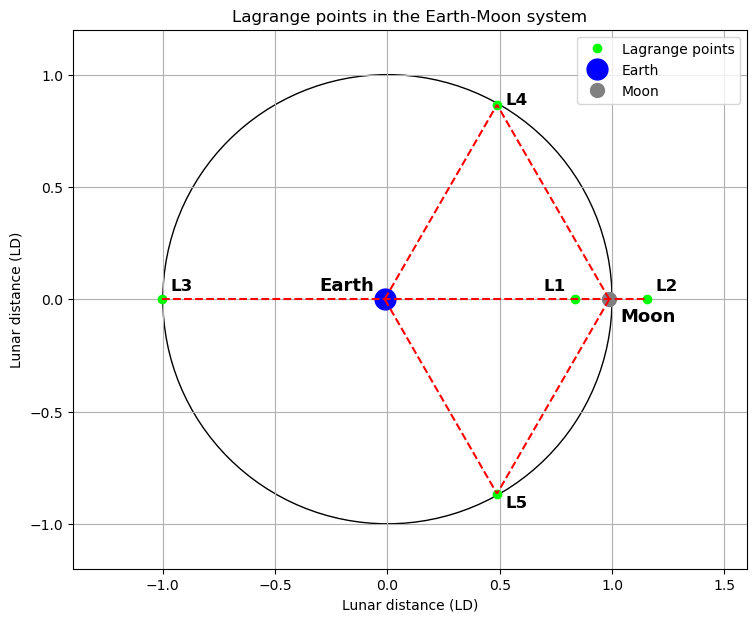

In [1147]:
#code for a lagrange point
#create a graph showing the lagrange points

# using https://orbital-mechanics.space/the-n-body-problem/Lagrange-points-example.html, 
# as  a walk through for the theory and steps on how to code the lagrange points
# there are coordinated for L4 AND L5, but L1,L2,L3 need to be calculated
# using the formula for the nondimensional position of the collinear Lagrange points

# for this system i will use a Earth-moon system
# define the mass ratio
Me = 5.972e24
Mm = 7.348e22
mu = Mm / (Me + Mm)

# define the formula for the nondimensional position of collinear Lagrange points, for L1,L2,L3
# consisted of 3 parts: x - big fraction 1 - big fraction 2
def collinear_lagrange(x, mu):
    bf1 = (1-mu)*(x+mu)/(np.abs(x+mu)**3)
    bf2 = mu*(x - 1 + mu)/(np.abs(x - 1 + mu)**3)
    return x - bf1 - bf2
    
# following the theoretical part of the walk through
# for L1,x0=0, for L2, x0=1, for L3, x0=-1
# use scipy.optimize.newton to solve L1,L2 and L3

from scipy.optimize import newton

# use func=collinear_lagrange, x0 = .., args=(mu,)
L1 = newton(func=collinear_lagrange, x0=0, args=(mu,))
L2 = newton(func=collinear_lagrange, x0=1, args=(mu,))
L3 = newton(func=collinear_lagrange, x0=-1, args=(mu,))

# now im defining L4 and L5 which have analytsical solutions
L4 = (0.5 - mu, np.sqrt(3)/2)
L5 = (0.5 - mu, -np.sqrt(3)/2)

# write out the lagrange points
print('L1 coordinates in LD:','(',round(L1,3),', 0 )')
print('L2 coordinates in LD:','(',round(L2,3),', 0 )')
print('L3 coordinates in LD:','(',round(L3,3),', 0 )')

# for L4 and L5, use L1[0] and round
print('L4 coordinates in LD:','(',round(L4[0],3),round(L4[1],3),')')
print('L5 coordinates in LD:','(',round(L5[0],3),round(L5[1],3),')')

# now i can plot the points on the graph, aswell as the masses
fig, ax = plt.subplots(figsize=(9,7))

#plot each point
# L1,L2,L3
ax.plot(L1,0,'o', label='Lagrange points',color='lime')
ax.plot(L2,0,'o',color='lime')
ax.plot(L3,0,'o',color='lime')

# plot l4 and l5 with the coordinates in the equation, essentially just write the coords
ax.plot(0.5 - mu, np.sqrt(3)/2,'o',color='lime')
ax.plot(0.5 - mu, -(np.sqrt(3)/2),'o',color='lime')

# Lagrange points are plotted, now plot mass points like in L4 and L5
ax.plot(-mu,0,'o',label='Earth',color='blue',markersize=15)
ax.plot(1 - mu,0,'o',label='Moon',color='gray',markersize=10)

# now plot circle and lines, as commonly seen for lagrange points, use plt circle and add_patch 
circle = plt.Circle((0,0), 1, fill = None, linestyle='-')
ax.add_patch(circle)

# using ax.plot(x_coordinates, y_coordinates) i can plot the dashed line between, Earth, Moon, L4,L5
ax.plot([-mu,0.5-mu],[0,np.sqrt(3)/2],linestyle='--',color='red')

#repeat for the other 3
ax.plot([-mu,0.5-mu],[0,-np.sqrt(3)/2],linestyle='--',color='red')
ax.plot([1 - mu,0.5 - mu],[0,np.sqrt(3)/2],linestyle='--',color='red')
ax.plot([1 - mu,0.5 - mu],[0,-np.sqrt(3)/2],linestyle='--',color='red')

#aswell as a line from L2 to L3
ax.plot([L3,L2],[0,0],linestyle='--',color='red')

# lock the box so the circle fits appropriately with the axis
ax.set_aspect('equal', adjustable='box')
ax.set_xlim(-1.4, 1.6)
ax.set_ylim(-1.2, 1.2)

# to show the points even clearer, i could add them next to each points, which is commonly found on lagrange point diagrams and masses
# will use ax.text(x, y, 'label') and manually change the postion till it fits next to the points well
ax.text(-0.29-mu, 0.04, 'Earth',fontsize=13, fontweight='bold')
ax.text(1.05-mu, -0.1, 'Moon',fontsize=13, fontweight='bold')
ax.text(L1-0.14, 0.04, 'L1',fontsize=12, fontweight='bold')
ax.text(L2+0.04, 0.04, 'L2',fontsize=12, fontweight='bold')
ax.text(L3+0.04, 0.04, 'L3',fontsize=12, fontweight='bold')
ax.text(0.54 - mu, np.sqrt(3)/2, 'L4',fontsize=12, fontweight='bold')
ax.text(0.54 - mu, -0.06-np.sqrt(3)/2, 'L5',fontsize=12, fontweight='bold')

# As ive now got the labels next to the points, i can change the legend and make all lagrange points are the same colour
# to easily do this ill just remove all the label code for the lagrange points but one and label it Lagrange points 
# aswell as the lines too
ax.legend()
ax.grid()

#titles
ax.set_title('Lagrange points in the Earth-Moon system')
ax.set_xlabel('Lunar distance (LD)')
ax.set_ylabel('Lunar distance (LD)')

plt.show()

This graph shows the lagrangian points of the Earth-Moon system, with 5 points located around the two masses, allowing for minimal fuel consumption. The points L1,L2 and L3 form in a straight line through the Earth and the moon, and the points L4 and L5 form at equilateral triangles to the distance between the Earth and the Moon. 

To connect all the points I added a bright dashed red line, clearly showing the locations of these points, aswell as a circle showing the orbit of the moon, or if a different system the orbit of the smaller larger mass. The Earth is at the centre of the graph and is to-scale in terms of distance, the size of the objects is not however.
I have also added a the coordinated of the lagrangian points, which are in lunar distance. However can easily be transferred to another system to find the positions by swapping lunar distance with the distance between the two masses. The x coordinate will then show the distance in the x-axis to these points, and the y coordinate will show the distance in the y-axis to these points.

## The circular and elliptical orbits, energy and momentum conservation 
The orbit of a smaller mass around a larger mass can be classified by being circular or elliptical. In space, it is most often found that the orbits are elliptical due to the complex nature of maintaining a perfectly circular orbit due to external forces. Circular orbits are often used for idealized models that simplify the calculations. 

#### Circular orbits:
In a circular orbit the velocity V remains constant due to a constant gravitational force on the mass, as the radius is constant, meaning no work is done in speeding up or slowing the mass. The linear momentum of the orbiting mass is not constant due to the direction continuously changing, however the total angular momentum for a closed system would be conserved. The angular momentum is conserved due to the net torque about the centre being zero. The total energy of the orbiting mass is constant due to no work being done on the object, resulting in the total energy being a combination of the two constants, kinetic and potential energy.

The velocity V of the orbiting mass:
$$v=\sqrt{\frac{GM}{r}}$$

The energy of the orbiting mass m:
$$E=-\frac{GMm}{2r}$$

The angular momentum L of the ciruclar orbiting mass:
$$L=m \sqrt(GMr)$$

#### Elliptical orbits:
In an elliptical orbit the velocity V is constantly changing due to the gravitational force constantly changing as the distance r from the centre of mass changes continuously. The total energy however remains constant, with the kinetic energy adn potential energy both varying as energy shifts forms between kinetic and potential and vice versa. Linear momentum is not conserved due to the direction and velocity of the orbiting mass m constantly changing. However angular momentum is conserved due to net torque about the centre being zero. This means the orbiting mass moves faster when closer to the mass it orbits and slower when further away.

The energy of orbting mass:
$$E=\frac{-GMm}{2a}$$

The angular momentum L of the elliptical orbiting mass:
$$L=m \sqrt(GMa(1-e^2)$$

Below I will produce a diagram of comparing the circular orbits to the elliptical orbits of the solar system, to do this I will produce a graph of the circular orbits and then a graph of the ciruclar orbits again but decreased in the y axis. I will then map these over the top of each other to easily show the difference in orbits that can occur. This graph will not be to-scale and will purely be to show the difference in circular and elliptical orbits. 

I will additionally compute a range of equations which can determine the velocity, total energy and angular momentum of an object which is in a circular or an elliptical orbit.

In [1159]:
# compute the equations into functions so that you put the function with variables and get the answer
# compute the equations into functions, if given 
# Start with velocity of orbiting mass for a circular orbit around earth
Me = 5.972e24
re = 6.38e6
Mo = 7.348e22

# velocity v of orbiting mass
def v_corbit_earth(d) :
    vcoe = (np.sqrt((sc.G*Me)/(re + d)))
    return f'The orbiting velocity of an object {d} metres above the surface for a circular orbit of the Earth is {round(vcoe,3)} m/s!'
    
# test for a geostationary orbit r = 35786e3 above equator
# accepted value is 3070 ms^-1
print(v_corbit_earth(35786e3))
#answer is close to accepeted value

# now doing for a mass that isnt earth
# rm is the radius of the larger mass, d is the distance from the surface to the orbiting object
def v_corbit_mass(M, rm, d) :
    vcom = (np.sqrt((sc.G*M)/(rm + d)))
    return f'The orbiting velocity of an object {d} metres above the surface for a circular orbit of the object with mass {M} kg is {round(vcom,3)} m/s!'
    
# test for the moon around the earth, accepted value of 1022 ms^-1
print(v_corbit_mass(Me, re, 384400e3))

# now doing the gpe for earth
def energy_corbit_earth(m, d) :
    ecoe = (-sc.G * Me * m)/(2 * (re + d))
    return f'The total orbital energy of an object of mass {m} kg, {d} metres above the surface for a circular orbit of the Earth is {round(ecoe,3)} J!'
    
# do at the geostationary orbit, with m = 1 for simplicity, d = 35786e3, accepted value is approx -4.73e6
print(energy_corbit_earth(1, 35786e3))


# now doing gpe for not earth
def energy_corbit_mass(M, m, r, d):
    ecom = (-sc.G * M * m)/(2*(r + d))
    return f'The total orbital energy of an object of mass {m} kg, {d} m above the surface for a circular orbit of the body of mass {M} kg is {ecom:.3e} J!'
    
# do the moon aswell, m= 7.35e22, accepted value is -3.8e28
print(energy_corbit_mass(Me, 7.35e22, re, 384400e3))


# now doing energy for elliptical orbit
# more realistic of being elliptical around the sun than a satellite around a planet, so will do earth sun system

Ms = 1.99e30
a = 149.6e9

# a is the semi major axis
# use p being a percentage of the semi major axis distance

def energy_earth_sun_eorbit() :
    eces = (-sc.G * Ms * Me)/(2*a)
    return f'The total orbital energy of the Earth in its elliptical orbit around the sun is {eces:.3e} J!'
    
# do at the semi major axis accepted value is -2.65e33
print(energy_earth_sun_eorbit())

#repeat for another system that is not earth and sun

def energy_Mm_eorbit(M, m, a) :
    eces = (-sc.G * M * m)/(2*a)
    return f'The total orbital energy of a mass {m} kg in its elliptical orbit around the larger mass {M} kg is {eces:.3e} J!'
    
# do at the semi major axis of the earth and sun, as values are known,  should get -2.65e33
print(energy_Mm_eorbit(Ms,Me,a))

def angmom_earth_sun_corbit(r): 
    L = Me * np.sqrt(Ms*sc.G*r)
    return f'The angular momentum of the earth {r} metres from the sun in a circular orbit is {L:.3e} kg m^2 s^-1!'
    
# test at exactly 1 au, accepted value is 2.66-2.68e40
print(angmom_earth_sun_corbit(149597870700))

#do for earth moon system
def angmom_earth_moon_corbit(r): 
    L = Mo * np.sqrt(Me*sc.G*r)
    return f'The angular momentum of the moon {r} metres from the earth in a circular orbit is {L:.3e} kg m^2 s^-1!'
    
# test at exactly 1 au, accepted value is 2.9e34
print(angmom_earth_moon_corbit(384400e3))

# now test for a system which isnt earth
def angmom_Mm_corbit(M, m, r): 
    L = m * np.sqrt(M*sc.G*r)
    return f'The angular momentum of the m {m} kg,{r} metres from the M {M} kg in a circular orbit is {L:.3e} kg m^2 s^-1!'
    
# for this system i will test on jupiter and io, accepted value is around 6.5e38
print(angmom_Mm_corbit(1.898e27, 8.93e22, 421700000)) 

# now for a elliptical orbit, same again just different equation
def angmom_earth_sun_eorbit(e): 
    L = Me * np.sqrt(Ms *sc.G *a*(1-e**2))
    return f'The angular momentum of the earth to the sun in an elliptical orbit ,with eccentricity of {e}, is {L:.3e} kg m^2 s^-1!'
    
# earth and sun, accepted value is 2.66-2.68e40
print(angmom_earth_sun_eorbit(0.0167))

aem = 384400e3

def angmom_earth_moon_eorbit(e): 
    L = Mo * np.sqrt(Me *sc.G *aem*(1-e**2))
    return f'The angular momentum of the moon to the earth in an elliptical orbit, with eccentricity of {e}, is {L:.3e} kg m^2 s^-1!'
    
# earth and moon, accepted value is 2.9e34
print(angmom_earth_moon_eorbit(0.0549))

# now do for other system, io around jupiter
def angmom_Mm_eorbit(M, m, a, e): 
    L = m * np.sqrt(M *sc.G *a*(1-e**2))
    return f'The angular momentum of the a {m} kg body elliptically orbiting a {M} kg, of semi major axis {a:.3e} m and eccentricity {e} is {L:.3e} kg m^2 s^-1!'
    
# jupiter and io, accepted value is around 6.5e38
print(angmom_Mm_eorbit(1.898e27,8.93e22, 4.217e8, 0.0041))

The orbiting velocity of an object 35786000.0 metres above the surface for a circular orbit of the Earth is 3074.55 m/s!
The orbiting velocity of an object 384400000.0 metres above the surface for a circular orbit of the object with mass 5.972e+24 kg is 1009.942 m/s!
The total orbital energy of an object of mass 1 kg, 35786000.0 metres above the surface for a circular orbit of the Earth is -4726428.829 J!
The total orbital energy of an object of mass 7.35e+22 kg, 384400000.0 m above the surface for a circular orbit of the body of mass 5.972e+24 kg is -3.748e+28 J!
The total orbital energy of the Earth in its elliptical orbit around the sun is -2.651e+33 J!
The total orbital energy of a mass 5.972e+24 kg in its elliptical orbit around the larger mass 1.99e+30 kg is -2.651e+33 J!
The angular momentum of the earth 149597870700 metres from the sun in a circular orbit is 2.662e+40 kg m^2 s^-1!
The angular momentum of the moon 384400000.0 metres from the earth in a circular orbit is 2.876e+3

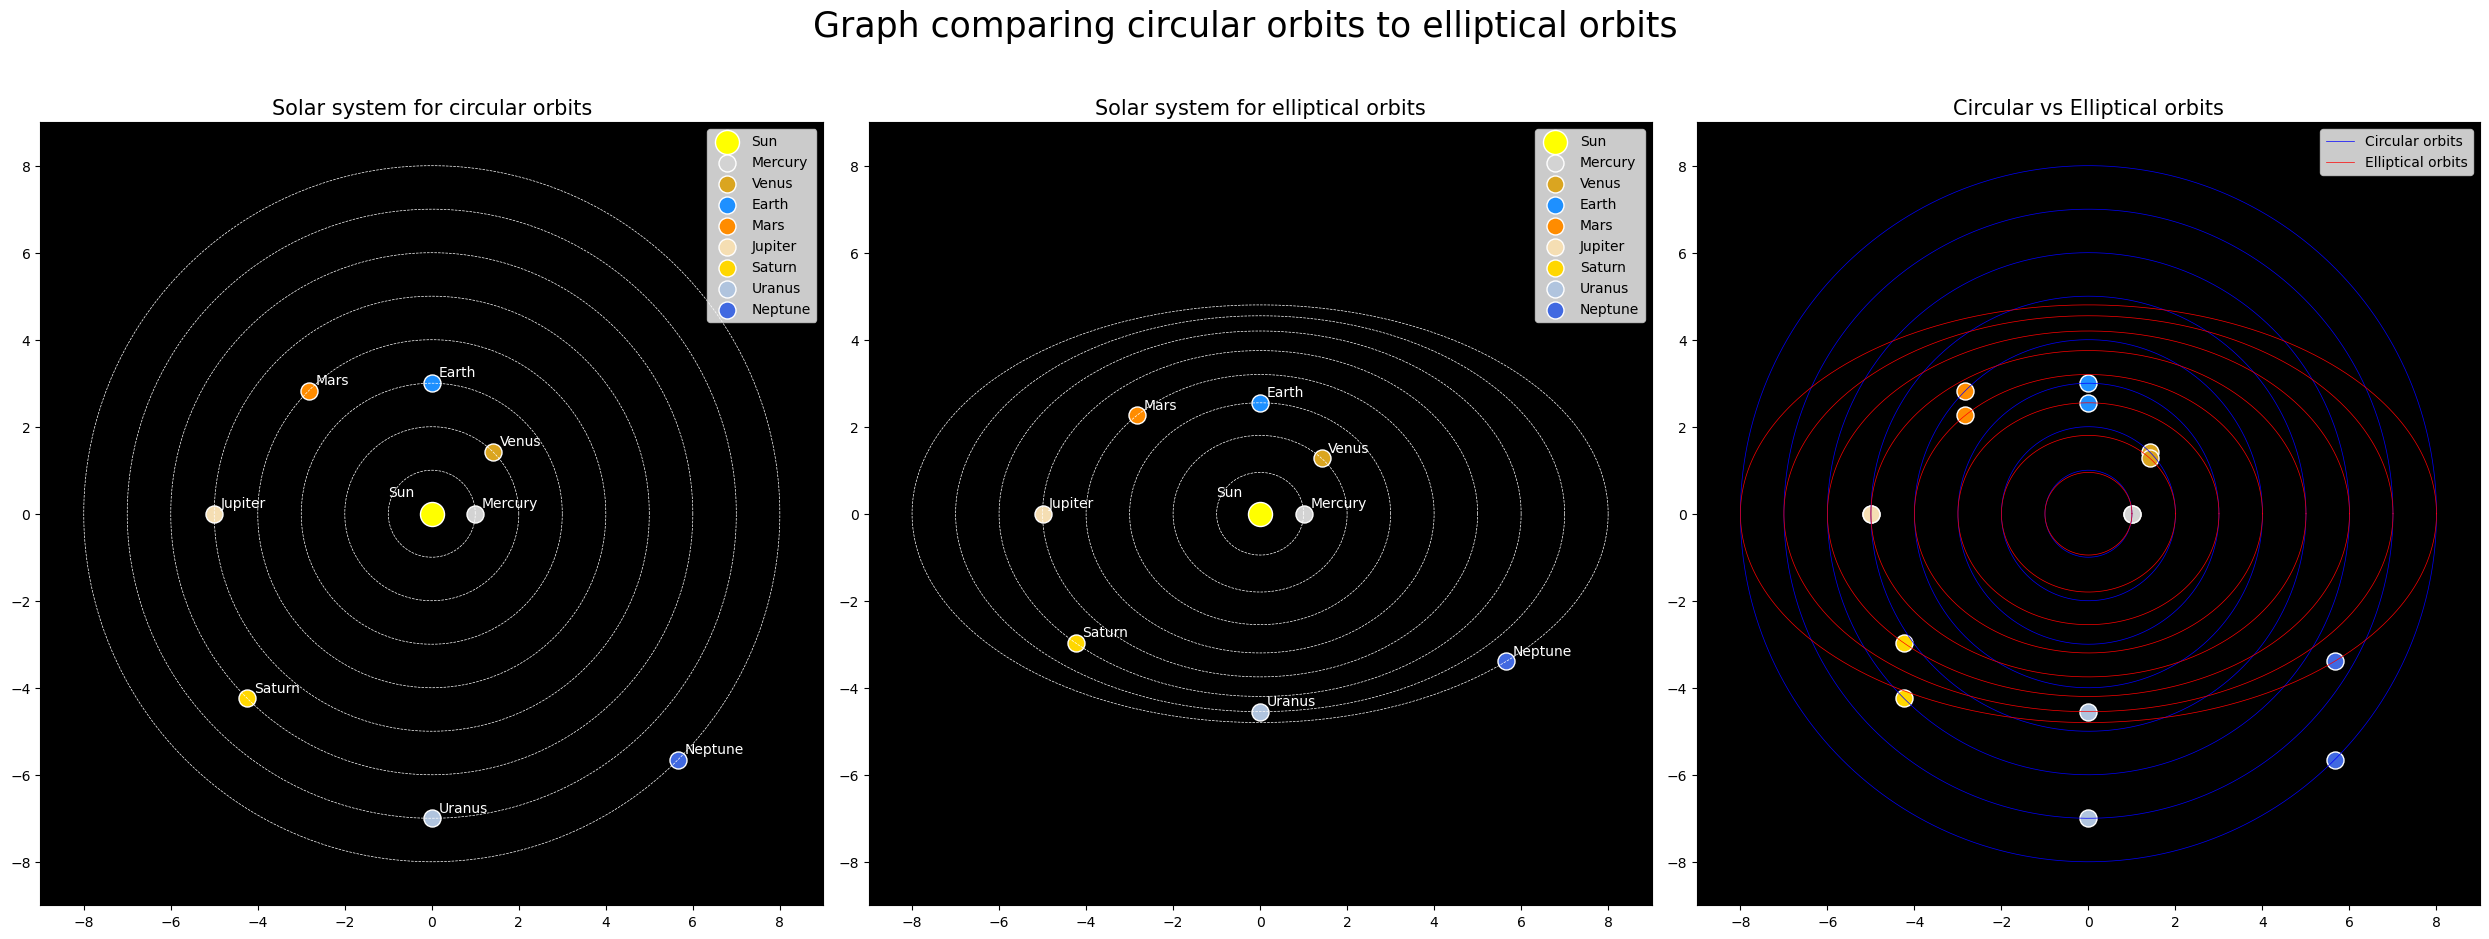

In [1150]:
# for this cell i will display the difference in the circular and elliptical orbits of our solar system
# before i do this code, in the finsihed product, i want two graphs next to each other 
# one elliptical and one spherical, showing how they are different and the eccentricity effects them

# i dont want these to be a scale size of the solar system, as planets close to the sun, mercury, venus, earth, mars will not be easily visible in the graph
# to do this i will use evenly spaced radii

# for circular ill use x=rcostheta, y =rsintheta; for elliptical ill use x = acostheta, y=bsintheta

# spread the planets out evenly so they dont clash
# essentially creating a non-scale diagram of the orbits

# define the names and colours of the planets within an array, make them match up to realistic colours
planets = ['Mercury','Venus','Earth','Mars','Jupiter','Saturn','Uranus','Neptune']
p_colours = ['lightgray','goldenrod','dodgerblue','darkorange','wheat','gold','lightsteelblue','royalblue']

# define the radii, flattening factor for elliptical and angle from the sun, so each has a different y position in arrays
# do all in increasing common factors, so can be displayed and understood easily

radii = np.array([1,2,3,4,5,6,7,8])

# ill decrease my factor gradually as outer shaped will need larger so dont overlap with inner
f_factor = np.array([0.95,0.9,0.85,0.8,0.75,0.7,0.65,0.6])

# increase the gradually up to 2 pi
angles = np.array([0*np.pi,0.25*np.pi,0.5*np.pi,0.75*np.pi,1*np.pi,1.25*np.pi,1.5*np.pi,1.75*np.pi])

#create the figure for both of the graphs
fig, ax = plt.subplots(1,3,figsize=(25,10))

# now gradually plot the planets and sun

######Circular orbit######


# start plot on ax0, for the circular orbit
ax[0].scatter(0,0, color = 'yellow', edgecolor = 'white', s = 300, label='Sun')

# define the range of theta
theta = np.linspace(0,2*np.pi,1000)

# problem when plotting, using i in range can easily solve this
# define the radii with angle
# as ive been able to use arrays, i can use i in range for each array to match up and make a simple code
# will have to plot in indent here too

for i in range(len(planets)):
    
    x_orbit = radii[i] * np.cos(theta)
    y_orbit = radii[i] * np.sin(theta)
    ax[0].plot(x_orbit, y_orbit, color='white', linestyle='dashed', linewidth = 0.5)
    
# define the angle of the radii from the suns position
    x_angle = radii[i] * np.cos(angles[i])
    y_angle = radii[i] * np.sin(angles[i])
    ax[0].scatter(x_angle,y_angle, color=p_colours[i],s=150, label=planets[i], edgecolor='white')
    
    ax[0].text(x_angle + 0.15, y_angle + 0.15, planets[i], color="white", fontsize=10)
    # going to change angles, so neptune is in a corner, so name can be fully displayed with all names at same position
    
# to make it look more like a solar system and display the planets more clealy, i will make the backdrop black, make lines white
ax[0].set_facecolor("black")

# a legend
ax[0].legend()

# plot the name for sun on the graph
ax[0].text(-1,0.4,'Sun', color='white', fontsize=10)

# set a title
ax[0].set_title('Solar system for circular orbits', fontsize=15)



#####Second graph#####



# now plot for ax1
# plot the sun first
ax[1].scatter(0,0, color = 'yellow', edgecolor = 'white', s = 300, label='Sun')

# make the graph black
ax[1].set_facecolor("black")

# now do the for i in range 
# copy all code over and adjust for ax[1]

for i in range(len(planets)):
    
    b = radii[i] * f_factor[i] 
    
# replace b for radii in y 
    x_eorbit = radii[i] * np.cos(theta) 
    y_eorbit = b * np.sin(theta) 
    ax[1].plot(x_eorbit, y_eorbit, color='white', linestyle='dashed', linewidth = 0.5) 
    
    # define the angle of the radii from the suns position 
    x_eangle = radii[i] * np.cos(angles[i]) 
    y_eangle = b * np.sin(angles[i]) 
    
    ax[1].scatter(x_eangle,y_eangle, color=p_colours[i],s=150, label=planets[i], edgecolor='white')
    ax[1].text(x_eangle + 0.15, y_eangle + 0.15, planets[i], color="white", fontsize=10)

    
# legend and title
ax[1].legend()
ax[1].set_title('Solar system for elliptical orbits', fontsize=15)

# issue of the ax[1] graph being ellipticsl in the y and not the x, to solve set x and y to the same, using set_aspect
ax[0].set_aspect('equal')
ax[1].set_aspect('equal')


# now an issue of ax[1] being smaller vertically, want to keep the same height so it easily shows the difference
# to solve this i will limits using set_xlim, set_ylim
ax[0].set_xlim(-9, 9)
ax[0].set_ylim(-9, 9)

ax[1].set_xlim(-9, 9)
ax[1].set_ylim(-9, 9)

# will add sun name too
ax[1].text(-1,0.4,'Sun', color='white', fontsize=10)



#####Third graph#####
# combination of first and second graph



# ill now change it to a 1,3 figure, on the third graph, ax[2] ill have the overlapping orbits, showing how the orbits change when elliptical even more clearly
# to do this ill just copy over both previous codes, rename and edit so the orbits can be easily seen, _comp at end for compare

# firstly ill make the backdrop black so graphings can easily be seen
ax[2].set_facecolor("black")

for i in range(len(planets)):
    
    x_orbit = radii[i] * np.cos(theta)
    y_orbit = radii[i] * np.sin(theta)
    
    if i == 0:
        ax[2].plot(x_orbit, y_orbit, color='blue', linestyle='solid', linewidth = 0.5, label = 'Circular orbits')
    else :
        ax[2].plot(x_orbit, y_orbit, color='blue', linestyle='solid', linewidth = 0.5)
        
# define the angle of the radii from the suns position
    x_angle = radii[i] * np.cos(angles[i])
    y_angle = radii[i] * np.sin(angles[i])
    
    ax[2].scatter(x_angle,y_angle, color=p_colours[i],s=150, edgecolor='white')
    
    b = radii[i] * f_factor[i] 
    
# replace b for radii in y 
    x_eorbit = radii[i] * np.cos(theta) 
    y_eorbit = b * np.sin(theta) 
    
    if i == 0:
        ax[2].plot(x_eorbit, y_eorbit, color='red', linestyle='solid', linewidth = 0.5, label='Elliptical orbits')
        
    else :
        ax[2].plot(x_eorbit, y_eorbit, color='red', linestyle='solid', linewidth = 0.5)
        
    # define the angle of the radii from the suns position 
    x_eangle = radii[i] * np.cos(angles[i]) 
    y_eangle = b * np.sin(angles[i]) 
    ax[2].scatter(x_eangle,y_eangle, color=p_colours[i],s=150, edgecolor='white')
    
#as both graph are extrapolated in y, do what i did before with set aspect and set on x and y lim
ax[2].set_aspect('equal')
ax[2].set_xlim(-9, 9)
ax[2].set_ylim(-9, 9)
ax[2].set_title('Circular vs Elliptical orbits', fontsize = 15)
ax[2].legend()


# as ive plotted both graph on top of each other, ill make the difference even clearer
# add different colours to the orbits, to show overlapping, remove names
# problem with the legend on ax[2], showing multiple for circular and elliptical, can solve this by using as if statement
fig.suptitle('Graph comparing circular orbits to elliptical orbits', fontsize=25)

# tight layout to make it look even more organised
plt.tight_layout()


plt.show()

Above are the three diagrams which clearly show the difference in the type of orbit that a object would take when orbiting. These orbits are different and vary on eccentricity and the semi-major axis to its orbiting body. These graphs are not too scale and are only to clearly show the differences in the types of orbit. I have also produced a range of equations which can be used to calculate the total energy, orbiting velocity and angular momentum for the Earth, an Earth-Moon system, an Earth-Sun system and for a different two massed bodied system.

Below I will create the elliptical orbits for our solar system in real scale, I will produce a circular orbit aswell to map over to visualize the true difference and what happens within our solar system. This is to scale model for the orbits, the only thing that is not too scale is the size of the planets which have been enlargened for visual aid. Due to the 4 planets in our solar system being close to the sun and having small orbits in comparison to the long-orbit planets, I will create two graphs. The left graph will show the whole solar system whereas the right graph will zoom in on the four large bodies that are closely orbiting the sun and will be difficult to see.

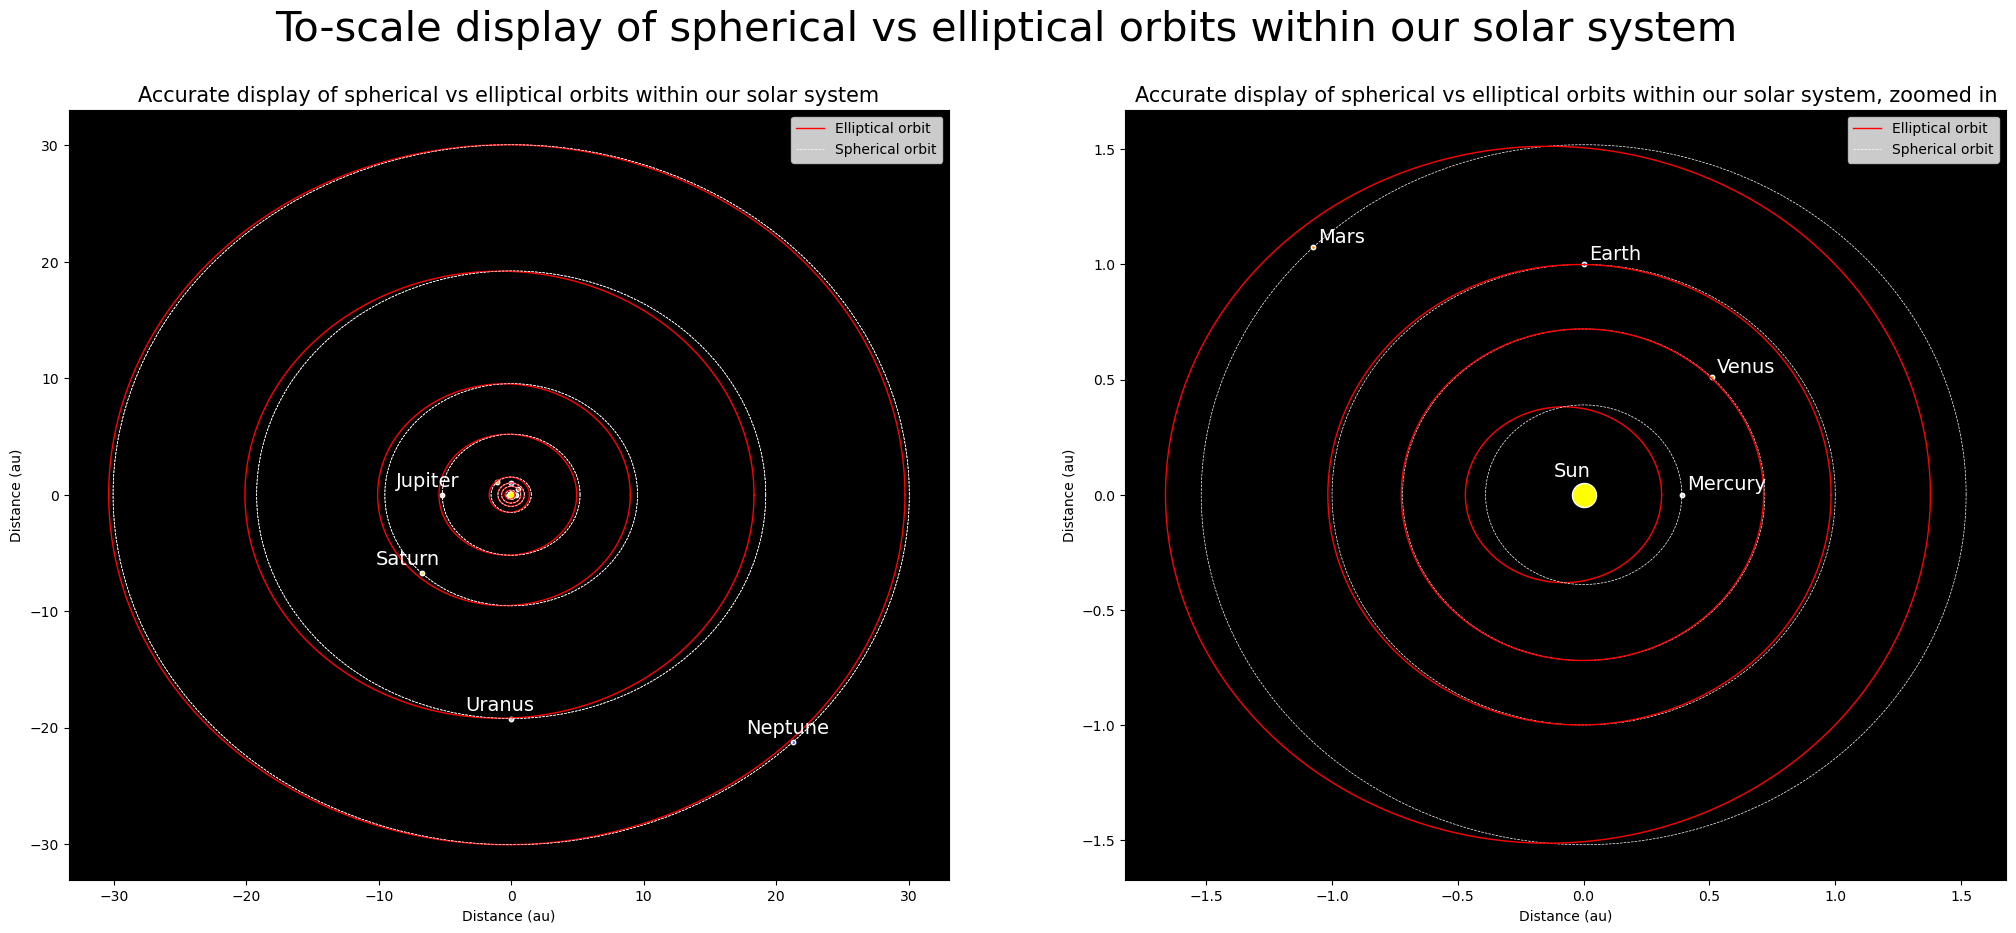

In [1151]:
# For this peice of code i will again do another solar system comparison, however this time i will make it realistic with the proportions, as the previous 3 graphs
# were just showing an overeall comparison

# for this comparison i will create 2 graphs, ax0 being the whole solar system and showing the planets with larger orbits clearly, and ax1 being the inner 4 planets
# which have much smaller orbits and will be difficult to see on ax0.

# to do this i will have to use eccentricity

# follow a very similar order and method to the previous code, however will use au distances for the radii instead, and eccentricity instead of the f_factor
# will copy necceasary code over from previous code and modify it

#define the planets in arrays so i can use them in for i range so its easy
planets = ['Mercury','Venus','Earth','Mars','Jupiter','Saturn','Uranus','Neptune']
p_colours = ['lightgray','goldenrod','dodgerblue','darkorange','wheat','gold','lightsteelblue','royalblue']


# for distance from the sun, still use radii so copying over is even easier from my previous code

a_radii = np.array([0.39,0.72,1.00,1.52,5.20,9.54,19.22,30.06])

ecc = np.array([0.2056, 0.0068, 0.0167, 0.0934, 0.0484, 0.057, 0.046, 0.011])

angles = np.array([0*np.pi,0.25*np.pi,0.5*np.pi,0.75*np.pi,1*np.pi,1.25*np.pi,1.5*np.pi,1.75*np.pi])


# set the figure up first
fig, ax = plt.subplots(1,2,figsize=(25,10))
ax[0].set_facecolor("black")
ax[1].set_facecolor("black")

# add a small sun into the centre of both graphs, sun for ax1 larger
ax[0].scatter(0,0, color = 'yellow', edgecolor = 'white', s = 30)
ax[1].scatter(0,0, color = 'yellow', edgecolor = 'white', s = 300)

# start with circular orbit
# start with graph ax0, once complete use a for loop and only plot on right graph mars and closer

# define theta 
theta = np.linspace(0,2*np.pi,1000)

for i in range(len(planets)):
    
    x_orbit = a_radii[i] * np.cos(theta)
    y_orbit = a_radii[i] * np.sin(theta)
    
    ax[0].plot(x_orbit, y_orbit, color='white', linestyle='dashed', linewidth = 0.5)
    
# define the angle of the radii from the suns position
    x_angle = a_radii[i] * np.cos(angles[i])
    y_angle = a_radii[i] * np.sin(angles[i])
    
    # make planets smaller than sun
    ax[0].scatter(x_angle,y_angle, color=p_colours[i],s=10, edgecolor='white')
    
    # as orbits in the centre are very close their labels are overlapping, ill use a for loop
    if i > 3:
        ax[0].text(x_angle - 3.5, y_angle + 0.7, planets[i], color="white", fontsize=14)
    else :
        None

    # now i need to produce the elliptical orbits on ax[0]
    # define b
    b = a_radii[i] * np.sqrt(1-ecc[i]**2)

    x_elorbit = a_radii[i] * (np.cos(theta) - ecc[i])
    y_elorbit = b * np.sin(theta)


    # plot orbit and planets, make it red
    # dont need to add planets as only showing the small but real change in orbits
    if i ==0:
        ax[0].plot(x_elorbit, y_elorbit, color='red', linewidth=1, label='Elliptical orbit')
        ax[0].plot(x_orbit, y_orbit, color='white', linestyle='dashed', linewidth = 0.5, label='Spherical orbit')
        
    else :
        ax[0].plot(x_elorbit, y_elorbit, color='red', linewidth=1)
        ax[0].plot(x_orbit, y_orbit, color='white', linestyle='dashed', linewidth = 0.5)
        
    # now as all plotted on ax[0] graph, just need to plot same two graphs on ax[1]
    # for this will use an if statement like earlier to remove orbits larger than mars, so is a nice zoomed in model
    # for ax1
    # use i<=3 to remove outer layers, do plot, scatter, text under this if i
    if i <= 3 :
        ax[1].scatter(x_angle,y_angle, color=p_colours[i],s=10, edgecolor='white')
        ax[1].text(x_angle + 0.02, y_angle + 0.02, planets[i], color='white', fontsize=14)
        
        # to get legend to work, if statment inside of an if statment
        if i == 0:
            ax[1].plot(x_elorbit, y_elorbit, color='red', linewidth=1, label='Elliptical orbit')
            ax[1].plot(x_orbit, y_orbit, color='white', linestyle='dashed', linewidth = 0.5, label='Spherical orbit')
            
        else :
            ax[1].plot(x_orbit, y_orbit, color='white', linestyle='dashed', linewidth = 0.5)
            ax[1].plot(x_elorbit, y_elorbit, color='red', linewidth=1)
    else :
        None

ax[1].text(-0.12,0.08,'Sun', color='white', fontsize=14)

# add final details like titles, axis titles etc, fix layout
ax[0].set_xlabel('Distance (au)')
ax[1].set_xlabel('Distance (au)')
ax[0].set_ylabel('Distance (au)')
ax[1].set_ylabel('Distance (au)')

ax[0].set_title('Accurate display of spherical vs elliptical orbits within our solar system', fontsize = 15)
ax[1].set_title('Accurate display of spherical vs elliptical orbits within our solar system, zoomed in', fontsize = 15)

# suptitle for big title
fig.suptitle('To-scale display of spherical vs elliptical orbits within our solar system', fontsize = 30)

# add a legend
ax[0].legend()
ax[1].legend()

plt.show()

The graphs above display both the real-scale in au orbits of the elliptical orbits taken and the simplified orbits of spherical orbits. The difference in colour clearly shows a variation between these orbits. It can also be seen that however elliptic the planet is, does not depend on the distance to the sun and only for the eccentricity and semi-major axis of the system.

Note : The planet size is not to scale to show help visually show the system

# The help and support used to create my project

As i have now completed the code for the topics that i intended, i am going to go back through my code and theory, improving the display of both so that they are easy to read and follow, removing unneeded comments where i had problems etc. After this i will clean up the section where I identify where i used ai and other sites to help me write my code.

In this section I will write the sites I used to help produce my project and where, and the ai codes and prompts that were used.

#### Searches

Throughout my coding I used google to search up various things for the theory, how to make the code presentable and how to use a certain function.

Examples of what i searched up are:
- gravitational field definition
- gravitational field around a point mass
- Latex example for code in python for equations to look fancy
- give me brief and short theory for ..., such as equations for these topics
- how to make letter bold in markdown cell
- how to do subscripts and summation
- in a def function, how can i make the sentence produced be in one line so its presentable - use {} and only 1 pair of speech marks around the whole thing.
- what are the different cmaps and colours that can be used on the presentation of a graph and colourbar
- how to add a point to a vector graph

#### Videos
To learn how to plot a vector field graph i watched :
visualizing vector fields, by physics with nero on Youtube. I followed his steps and completed the questions on his video whilst learning the various codes that are required to produce the graph. 

From this, I learnt the code of various vector graphs, allowing me to display vector and contour graphs in the graviational field strength and gravitational potential around 1,2,n point masses.

#### Websites
To learn various aspects and help undeerstand different functions, especially vector graph function as these are new to me I used several websites in order to aid my coding and theory of my project, these allowed me to accurately perform various functions and produce wokring code.

- matplotlib.org, to explain different functions and give examples on how to use them
- orbital-mechancis.space, specifically ,https://orbital-mechanics.space/the-n-body-problem/Lagrange-points-example.html, in which i followed along to learn how to plot the lagrangian point graph, went through theory and what functions to use etc
- python.org - to explain different fucntions and give examples on how to use them

#### Use of AI
Through parts of the project i have used AI in order to explain various functions, and give examples on how they could be used. I additionally used it for questions such that would help me finsih the code and make the code more presentable. These code would be copied in and learnt on how they work and I would then adjust it in order to fit my code so that it can function as wanted. The AI I used was OpenAi. I will give the prompts that i used and the code that it gave, the explanations of what the code does would not necessary and would be space-consuming.

- 'How can i write a colourbar into my code in python?'
    cbar = fig.colorbar(Vstrength, ax=ax,label='Gravitational potential (V)', location='right', shrink=0.9) 

- 'How can i add a circle onto a graph?'
    used circle = plt.Circle((0,0), 1, fill=False, linestyle='--') ax.add_patch(circle)

- 'How can i make my graph not stretched in the y direction and be the same length for both axis?'
    ax.set_aspect('equal', adjustable='box') ax.set_xlim(-1.2, 1.2) ax.set_ylim(-1.2, 1.2)

- 'On my vector graph in python that is showing the gravitational field strength, has arrows that are pointing outwards and are very large and disrupting the graph how cani get rid of these?' - This was essential for my vectors as it made the graph look unusual
    #find the magnitude of each vector
    mag1 = np.sqrt(fx1**2 + fy1**2)
    #cap the vector to a max allowed size
    cap1 = np.percentile(mag1, 90)
    #scale each vector by getting the scalar factor
    scale_factor1 = np.minimum(1,cap1/mag1)
    #scale the vectors
    fx1 = fx1 * scale_factor1
    fy1 = fy1 * scale_factor1

- 'How can i make the colourbar show log graph?' - For field strength on my colour bar
    from matplotlib.colors import LogNorm

- 'How can i plot a point on my vector graph to make to change the gravitational field for multiple masses?'
    dx2 = x - p2[0]
    dy2 = y - p2[1]
    r2 = np.sqrt(dx2**2 + dy2**2)
    g2x = (-G * mass2 * dx2)/r2**2
    g2y = (-G * mass2 * dy2)/r2**2

- 'How can i change the colour bar so that the colours are flipped or i can change the axis labels?' - this was needed for the gravitational potential colourbar which was inverted and the colour wasn't changing
    #define the colourbar with vstrength in
    #use linspace for ticks
    ticks = np.linspace(min,max,n)
    #set ticks with labels
    cbar.set_ticks(ticks)
    cbar.set_ticklabels([])

- 'How can i set a limit to the graph so it stays presentable and able to compare each graph easily?' - needed for comparing the spherical and elliptical orbits
    ax[0].set_xlim(-9, 9)
    ax[0].set_ylim(-9, 9)
    ax[1].set_xlim(-9, 9)
    ax[1].set_ylim(-9, 9)